# Loading required libraries

In [1]:
library(ggplot2)
library(patchwork)
library(scales)
library(ggradar)
library(tidyverse)
library(ggpubr)
library(ggbeeswarm)
library(ComplexHeatmap)
library(circlize)
library(survminer)
library(survival)
library(showtext)
font_add("Arial", "/System/Library/Fonts/Supplemental/Arial.ttf")
showtext_auto()

Warning message:
“package ‘ggplot2’ was built under R version 4.4.3”
Warning message:
“package ‘tibble’ was built under R version 4.4.3”
Warning message:
“package ‘tidyr’ was built under R version 4.4.3”
Warning message:
“package ‘readr’ was built under R version 4.4.3”
Warning message:
“package ‘purrr’ was built under R version 4.4.3”
Warning message:
“package ‘dplyr’ was built under R version 4.4.3”
── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.0     ✔ readr     2.1.6
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ lubridate 1.9.4     ✔ tibble    3.3.1
✔ purrr     1.2.1     ✔ tidyr     1.3.2
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ readr::col_factor() masks scales::col_factor()
✖ purrr::discard()    masks scales::discard()
✖ dplyr::filter()     masks stats::filter()
✖ dplyr::lag()        masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to becom

## Figures and Files Setup

In [2]:
data_dir = "/Users/jawadalaaedeen/Desktop/PhD/NMC/results"
results_dir = "/Users/jawadalaaedeen/Desktop/PhD/NMC/results/figure_6"

# Color palettes

In [3]:
myeloid_palette <- c(
  "MDSCs" = "#332288",
  "M2 macrophages" = "#66A61E",
  "M1 macrophages" = "#00557F",
  "M1/M2 macrophages" = "#BBCCEE",
  "DCs" = "#E69F00",
  "Granulocytes" = "#B85AA6",
  "Mast cells" = "#8E006A"
)

lymphoid_palette <- c(
  "CD8+ T cells" = "#B2182B",
  "CD4+ T cells" = "#EF8A62",
  "Treg T cells" = "#FFCCCC",
  "NK cells" = "#0096FF",
  "B cells" = "#E6C84F",
  "PCs" = "#F4E58A"
)

non_immune_palette <- c(
  "Actin+ cells" = "#B39DDB",
  "Endothelial cells" = "#7F8F6A",
  "Lymphatic endothelial cells" = "#A6B08A",
  "Epithelial cells" = "#E3B07A"
)


other_palette <- c(
  "Tumor cells" = "#44AA99",
  "NFC" = "#DDDDDD"
)

full_palette <- c(
  myeloid_palette,
  lymphoid_palette,
  non_immune_palette,
  other_palette
)

tumor_site_colors <- c(
"Lung" = "#F0F0F0",     # very light
"Head and Neck" = "#B0B0B0",  # medium
"Extrahepatic" = "#505050" # darker
)

# Load the required data

In [4]:
celltype_metadata <- read_csv(
  paste0(data_dir, "/celltype_metadata_final.csv")
) %>%
  mutate(is_lung = ifelse(tumor_site == "Lung", "Lung", "Head and Neck/Extrahepatic")) %>%
  mutate(patient_num = as.numeric(str_extract(patient_exp, "(?<=NUT_)\\d+")),
         roi_num = as.numeric(str_extract(patient_exp, "(?<=ROI)\\d+"))) %>%
  arrange(patient_num, roi_num) %>%
  select(-patient_num, -roi_num)
celltype_metadata$patient_exp <- factor(celltype_metadata$patient_exp, levels = unique(celltype_metadata$patient_exp))
celltype_metadata$patient_ID <- factor(celltype_metadata$patient_ID, levels = unique(celltype_metadata$patient_ID))
patient_ID_order <- unique(celltype_metadata$patient_ID)
patient_exp_order <- unique(celltype_metadata$patient_exp)


myeloid <-  c("M1 macrophages", "M2 macrophages", "M1/M2 macrophages", "DCs", "Granulocytes", "MDSCs", "Mast cells")
lymphoid <- c("CD4+ T cells", "CD8+ T cells", "Treg T cells", "NK cells", "B cells", "PCs")
nonimmune <- c("Actin+ cells", "Endothelial cells", "Lymphatic endothelial cells", "Epithelial cells")

celltype_metadata <- celltype_metadata %>%
  mutate(
    cell_category_simplified = case_when(
      cell_category %in% myeloid ~ "Myeloid",
      cell_category %in% lymphoid ~ "Lymphoid",
      cell_category %in% nonimmune ~ "Non-immune",
      cell_category == "NFC" ~ "NFC",
      cell_category == "Tumor cells" ~ "Tumor"
    ),
    cell_category_simplified = factor(
      cell_category_simplified,
      levels = c("NFC", "Non-immune", "Lymphoid", "Myeloid", "Tumor")
    )
  ) 

Rows: 553331 Columns: 12
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (6): cell_type, cell_category, patient_ID, exp_name, patient_exp, tumor_...
dbl (6): cell_id, Cell Center X, Cell Center Y, run, rois, survival_time_months

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [5]:
survival_df <- celltype_metadata %>%
    select(patient_ID, tumor_site, survival_time_months) %>%
    distinct() %>%
    mutate(event = ifelse(patient_ID == "NUT_1", 0, 1),
        tumor_site = factor(tumor_site, levels = c("Lung", "Head and Neck", "Extrahepatic")), 
    patient_ID = factor(patient_ID, levels = patient_ID_order),
    is_lung = ifelse(tumor_site == "Lung", "Lung", "Head and Neck/Extrahepatic"),
        event = as.numeric(event),
        survival_time_months = as.numeric(survival_time_months)
      )

survival_df_order <- survival_df %>%
arrange(tumor_site, survival_time_months) %>%
mutate(patient_ID = factor(patient_ID, levels = unique(patient_ID)))

patient_ID_survival_order <-survival_df_order %>%
pull(patient_ID)

# B

### for plot B, refer to the COZI folder

# C

In [15]:
plot_highlight <- function(df, highlight_levels, title = NULL,
                           bg_color = "#D9D9D9", bg_alpha = 1,
                           pt_size_bg = 1.5, pt_size_fg = 1.5) {

  df_bg <- df %>% dplyr::filter(!cell_category %in% highlight_levels)
  df_fg <- df %>% dplyr::filter(cell_category %in% highlight_levels)

  # palette restricted to highlighted cells (keeps your exact colors)
  pal_hl <- full_palette[highlight_levels]
  pal_hl <- pal_hl[!is.na(pal_hl)]  # safety if some names not present

  ggplot() +
    geom_point(
      data = df_bg,
      aes(x = `Cell Center X`, y = `Cell Center Y`),
      color = bg_color,
      alpha = bg_alpha,
      size = pt_size_bg
    ) +
    geom_point(
      data = df_fg,
      aes(x = `Cell Center X`, y = `Cell Center Y`, color = cell_category),
      alpha = 0.95,
      size = pt_size_fg
    ) +
    scale_color_manual(
      values = pal_hl,
      breaks = highlight_levels,   # <- legend entries limited to highlighted
      drop = TRUE
    ) +
    coord_equal() +
    theme_void() +
    theme(
      legend.title = element_blank(),
      plot.title = element_text(hjust = 0.5),
      legend.position = "none"
    ) +
    ggtitle(title) +
    scale_y_reverse()
}  


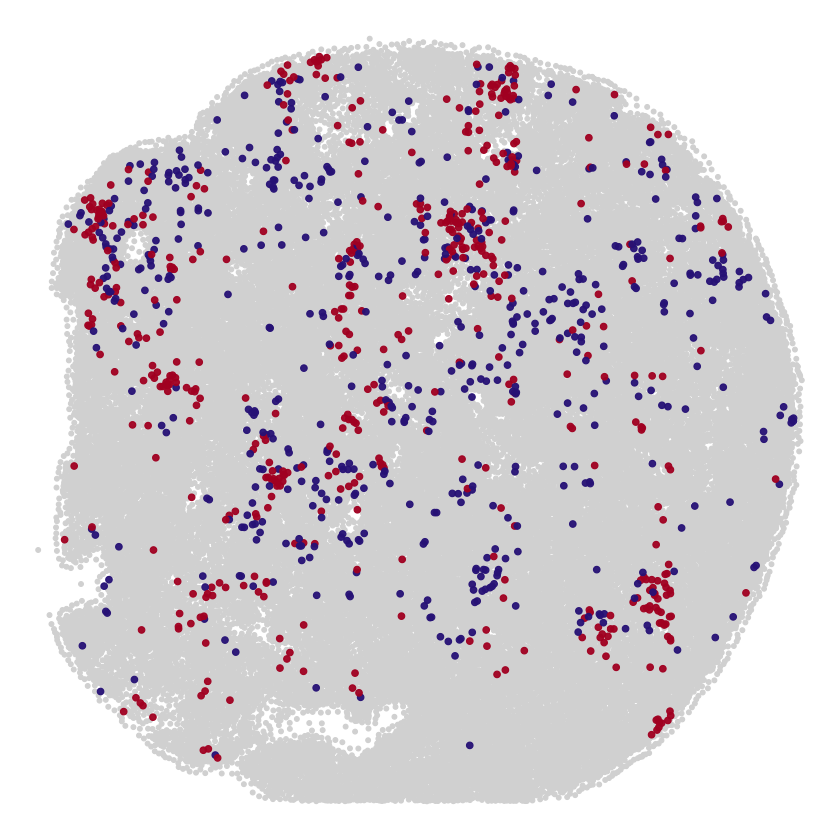

In [18]:
exp <- "NUT_5_ROI11"
df <- celltype_metadata %>%
  filter(patient_exp == exp)

p <- plot_highlight(
  df,
  pt_size_bg = 1, pt_size_fg = 1.5,
  highlight_levels = c("MDSCs", "CD8+ T cells"))
p

ggsave(filename = file.path(results_dir, "NMC_5_ROI11_mdscscd8.pdf"),
       plot = p,
       width = 10,
       height = 10,
       dpi = 300,
       bg = "white")

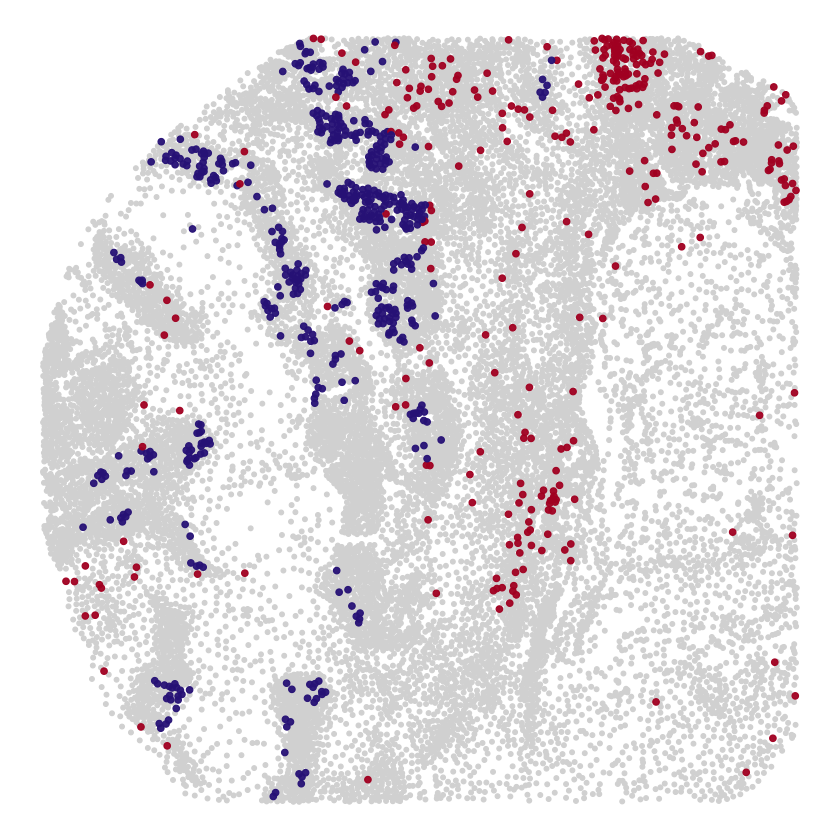

In [24]:
exp <- "NUT_7_ROI13"
df <- celltype_metadata %>%
  filter(patient_exp == exp)

p <- plot_highlight(
  df,
  pt_size_bg = 1, pt_size_fg = 1.5,
  highlight_levels = c("MDSCs", "CD8+ T cells"))
p

ggsave(filename = file.path(results_dir, "NMC_7_ROI13_mdscscd8.pdf"),
       plot = p,
       width = 10,
       height = 10,
       dpi = 300,
       bg = "white")

# D

In [34]:
#calculate proportions of mdscs for NUT_5 and NUT_7
mdscs_percentage <- celltype_metadata %>%
  filter(patient_ID %in% c("NUT_5", "NUT_7")) %>%
  group_by(patient_ID, patient_exp, cell_category) %>%
    summarise(count = n()) %>%
    ungroup() %>%
    group_by(patient_ID, patient_exp) %>%
    mutate(proportion = count / sum(count)) %>%
    #calculate mean per patient
    group_by(patient_ID, cell_category) %>%
    summarise(mean_proportion = mean(proportion)) %>%
    ungroup() %>%
    filter(cell_category %in% c("MDSCs", "CD8+ T cells")) %>%
    mutate(percentage = mean_proportion * 100)
mdscs_percentage

`summarise()` has regrouped the output.
ℹ Summaries were computed grouped by patient_ID, patient_exp, and
  cell_category.
ℹ Output is grouped by patient_ID and patient_exp.
ℹ Use `summarise(.groups = "drop_last")` to silence this message.
ℹ Use `summarise(.by = c(patient_ID, patient_exp, cell_category))` for
  per-operation grouping (`?dplyr::dplyr_by`) instead.
`summarise()` has regrouped the output.
ℹ Summaries were computed grouped by patient_ID and cell_category.
ℹ Output is grouped by patient_ID.
ℹ Use `summarise(.groups = "drop_last")` to silence this message.
ℹ Use `summarise(.by = c(patient_ID, cell_category))` for per-operation
  grouping (`?dplyr::dplyr_by`) instead.


patient_ID,cell_category,mean_proportion,percentage
<fct>,<chr>,<dbl>,<dbl>
NUT_5,CD8+ T cells,0.01589405,1.589405
NUT_5,MDSCs,0.01801069,1.801069
NUT_7,CD8+ T cells,0.01081275,1.081275
NUT_7,MDSCs,0.02257018,2.257018


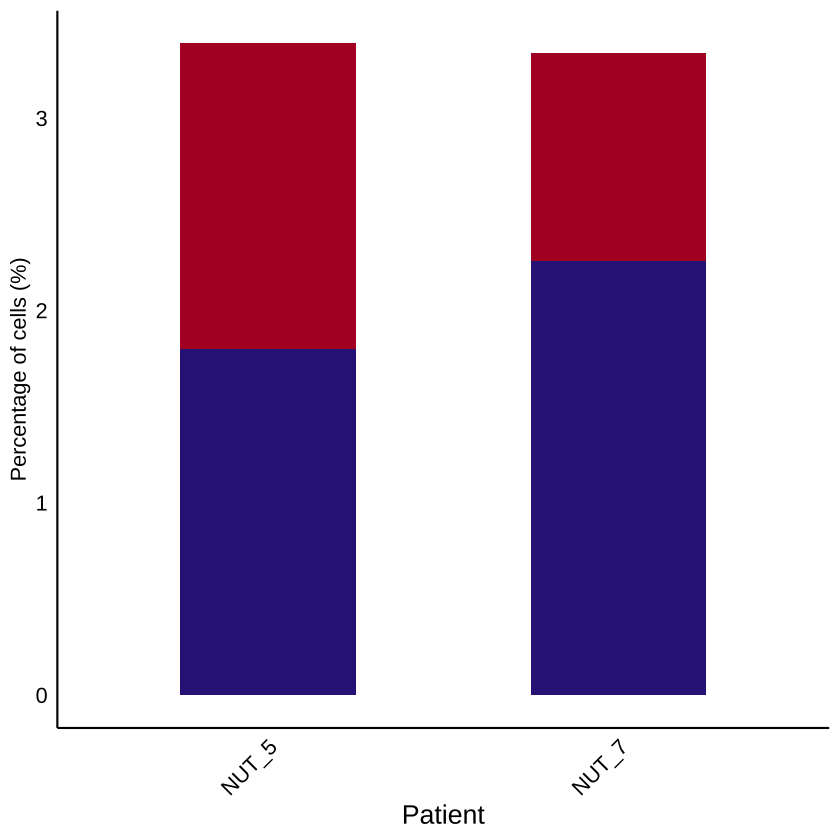

In [40]:
#barplot for comparison 
comparison_barplot <- ggplot(
  mdscs_percentage,
  aes(x = patient_ID, y = percentage, fill = cell_category)
) +
  geom_bar(stat = "identity", width = 0.5) +
  scale_fill_manual(values = full_palette) +
  guides(fill = guide_legend(reverse = TRUE)) +
  labs(
    x = "Patient",
    y = "Percentage of cells (%)",
    fill = "Cell type"
  ) +
  theme_minimal(base_size = 13) +
  theme(
    axis.text.y  = element_text(size = 13, colour = "black"),
    axis.title.y = element_text(size = 13),
    axis.text.x = element_text(size = 13, angle = 45, hjust = 1, vjust = 1, colour = "black"),
    axis.title.x = element_text(size = 16, colour = "black"),
    axis.title  = element_text(size = 13, colour = "black"),
    legend.text  = element_text(size = 13),
    legend.title = element_text(size = 13),
    legend.key.height = unit(0.5, "cm"),
    legend.position = "none",
    panel.border = element_blank(),

    axis.line.x.bottom = element_line(colour="black", linewidth=0.6),
    axis.line.x.top    = element_line(colour="black", linewidth=0.6),
    axis.line.y.left   = element_line(colour="black", linewidth=0.6),
    axis.line.y.right  = element_blank(),

    axis.text.x.top  = element_blank(),
    axis.ticks.x.top = element_blank(),
    axis.title.x.top = element_blank(),

    panel.grid = element_blank())

comparison_barplot

ggsave(
  filename = file.path(results_dir, "patientmdscscd8_composition_barplot.pdf"),
  plot = comparison_barplot,
  width = 3,
  height = 4,
  dpi = 300,
  bg = "white"
)

# E

In [10]:
interaction_df <- read.csv(file.path(data_dir, "myeloid_t_interactions.csv"))
mdscs_interaction <- interaction_df %>%
    filter(celltype_A == "MDSCs")

patient_ID,cell_pair,zscore,zscore_normalized,cond_percent,celltype_A,celltype_B
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
NUT_9,MDSCs-CD8+ T cells,22.90577426,0.1109604350,11.2273803,MDSCs,CD8+ T cells
NUT_9,MDSCs-CD4+ T cells,16.53165210,0.1089491569,11.8829516,MDSCs,CD4+ T cells
NUT_2,MDSCs-CD8+ T cells,5.29554098,0.0357447988,4.7872340,MDSCs,CD8+ T cells
NUT_2,MDSCs-CD4+ T cells,3.29310939,0.0222284245,7.4468085,MDSCs,CD4+ T cells
NUT_4,MDSCs-CD8+ T cells,8.73839821,0.0561342908,20.0294551,MDSCs,CD8+ T cells
NUT_4,MDSCs-CD4+ T cells,4.00442520,0.0257238871,6.9219440,MDSCs,CD4+ T cells
NUT_8,MDSCs-CD8+ T cells,7.60749751,0.0481496828,3.4532374,MDSCs,CD8+ T cells
NUT_8,MDSCs-CD4+ T cells,1.46880635,0.0092964289,5.3237410,MDSCs,CD4+ T cells
NUT_15,MDSCs-CD8+ T cells,1.18428955,0.0094483742,4.3135436,MDSCs,CD8+ T cells


In [14]:
for(tcell in c("CD4+ T cells", "CD8+ T cells")){
mdscs_interaction_filtered <- mdscs_interaction %>%
        filter(celltype_B == tcell) %>%
        mutate(group = factor(
    ifelse(is.na(zscore), "Low NEP", ifelse(zscore > 5, "High NEP", "Low NEP")),
    levels = c("High NEP", "Low NEP"))) %>%
    left_join(., survival_df %>% select(patient_ID, survival_time_months, event), by = "patient_ID")
     # Fit survival
    fit <- survfit(Surv(survival_time_months, event) ~ group, data = mdscs_interaction_filtered)
  
    # Plot
    surv_plot <- ggsurvplot(
      fit,
      data = mdscs_interaction_filtered,
      pval = TRUE,
      conf.int = TRUE,
      risk.table = TRUE,
      risk.table.height = 0.25,
      pval.coord = c(17, 0.7),
      xlim = c(0, 20),
      break.time.by = 5,
      palette = c("#2E86AB", "#E74C3C"),
      xlab = "Time (months)",
      ylab = "Survival probability",
      title = paste("Survival by", "MDSCs", "-", tcell, "NEP"),
      legend.title = paste0("MDSCs", "-", tcell),
      legend.labs = c("Low NEP", "High NEP"),
      risk.table.y.text.col = TRUE,
      risk.table.y.text = FALSE,
      ggtheme = theme_classic(base_size = 13, base_family = "Arial")
    )
    filename <- paste0(results_dir, "/survival_", "MDSCs", "_", tcell, ".pdf")
    ggsave(
    filename = filename, 
    plot = surv_plot$plot, 
    width = 7, 
    height = 6, 
    dpi = 300)
    filename <- paste0(results_dir, "/survival_table_", "MDSCs", "_", tcell, ".pdf")
    ggsave(
    filename = filename, 
    plot = surv_plot$table, 
    width = 7, 
    height = 2, 
    dpi = 300)
    }

Ignoring unknown labels:
• colour : "MDSCs-CD4+ T cells"
Ignoring unknown labels:
• colour : "MDSCs-CD8+ T cells"
